Input: coins.jpg 

Output: document_scanner Pipeline:

Input image →
grayscale →
median blur →
Hough Circle →
Circle detection →
center and radius extraction →
circle counting →
output.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

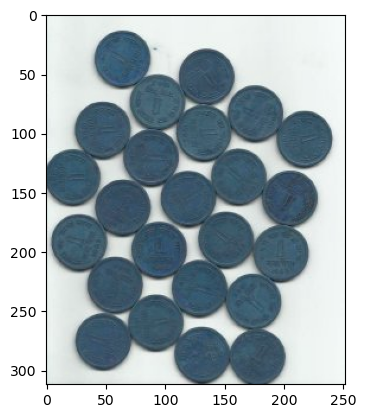

In [2]:
# read image
image = cv2.imread('coins.jpeg')
img_2 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [3]:
# # gray
# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# plt.imshow(gray)

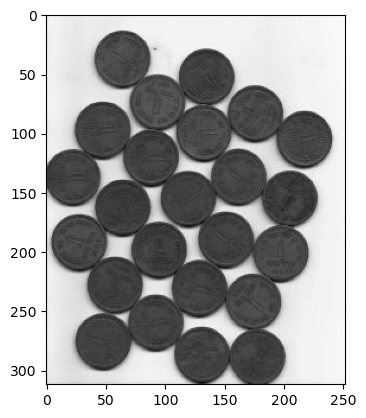

In [4]:
# gray
gray = cv2.cvtColor(img_2, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap = 'gray')

In [5]:
# reduce the noise
gray = cv2.medianBlur(gray, 5) # kernel size = 5


In [6]:
# detect circle

circles =cv2.HoughCircles(gray,  # image
                         cv2.HOUGH_GRADIENT, # detect
                         dp= 1.2,  # controls the resolution
                         minDist = 30,  # minimum distances between circle 
                         param1 =100, # higher threshol
                         param2 = 33, # larger make more selective
                         minRadius = 10, # small circle
                         maxRadius = 150) # large circle

In [7]:
if circles is not None:
    circles = circles[0].astype(int) # (x,y)=> for center,r => radius
    for x,y,r in circles:
        cv2.circle(image, (x,y), r, (0,0,255),2)
        #cv2.circle(image,(x,y), 3,(0,0,255),-1)

In [8]:
# count the coins
print("Circle detected: ", 0 if circles is None else len(circles))

Circle detected:  24


In [9]:
# save it
cv2.imwrite("coins detected.jpg", image)

True

In [10]:
cv2.imshow("circle", image)
cv2.waitKey(0)
cv2.destroyAllWindows()